<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/gd-test/QuintaCopiaSCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run this command if you want to remove your current folder

In [1]:
%%capture
!rm -rf /content/IHTest_202104_DistStA/
%mkdir -p /content/IHTest_202104_DistStA/test_data
%cd /content

Loading some data from the 202104 collection of the Darpa Invisible Headlights dataset

In [2]:
%%capture
!pip install spectral
!pip install awscli -q
!pip install laspy

In [3]:
%%capture
!aws s3 sync \
  s3://ihdataset-01/IHTest_202104_DistStA/Path15_DistStA/Path15_Step16_DistStA/ \
  /content/IHTest_202104_DistStA/test_data \
  --no-sign-request \
  --exclude "*" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.hdr" \
  --include "*Path15_Step16_BBVISRIGHT_DistStA.raw" \
  --include "*LWHSI1_collect1_DistStA.hdr" \
  --include "*LWHSI1_collect1_DistStA.bsq"

In [4]:
%%capture
! rm -rf /content/IHTest_202104_DistStA/depth_data
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/IHTest_202104_DistStA/depth_data
%cd /content/IHTest_202104_DistStA/depth_data
! git sparse-checkout set --no-cone depth
! git checkout
%cd ..

Loading the some data from Unay's GitHub for the scene

In [5]:
%%capture
! rm -rf /content/attenuation
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/unaydorken/Ozone-Cues-Mitigate-Reflected-Downwelling-Radiance-in-LWIR-Absorption-Based-Ranging /content/attenuation
%cd /content/attenuation
! git sparse-checkout set --no-cone data/attenuation.mat data/I_downwelling_res.mat data/lambda.mat
! git checkout

Loading the Ecostress Spectral Library

In [6]:
%%capture
! rm -rf /content/ecostress_spectral
%cd ..
! git clone -n --depth=1 --filter=tree:0 \
  https://github.com/MarinPedro/ThermalProject2026_HOCV /content/ecostress_spectral
%cd /content/ecostress_spectral
! git sparse-checkout set --no-cone ecostress
! git checkout

Importing libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob
import plotly.graph_objects as go
from pathlib import Path
from sklearn.cluster import KMeans
from skimage.color import rgb2gray
from sklearn.cluster import KMeans
from skimage.transform import resize
import scipy.io as sio

Implementing the functions used for the notebook

In [8]:
MICROFLICK_PER_W_M2 = 100.0

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

def crop_valid_region(img, pad_rows=2, pad_cols=8):
    """
    Automatically crops the region containing valid measurements.
    This helps prevent images with too much empty space.
    """
    valid = np.isfinite(img)

    if not valid.any():
        return img

    rows = np.where(valid.any(axis=1))[0]
    cols = np.where(valid.any(axis=0))[0]

    r0 = max(0, rows.min() - pad_rows)
    r1 = min(img.shape[0], rows.max() + pad_rows + 1)
    c0 = max(0, cols.min() - pad_cols)
    c1 = min(img.shape[1], cols.max() + pad_cols + 1)

    return img[r0:r1, c0:c1]


def plot_range_image(
    range_img,
    title="Range image LiDAR — inverse depth (No fov calibration)",
    crop=True,
    inverse_depth=False,
    percentile_clip=(2, 98),
    figsize=(20, 3),
):
    """
    Cleaner visualization of a range image.

    crop=True crops the region containing data.
    inverse_depth=True displays 1/r closeness, useful for making nearby objects stand out.
    percentile_clip prevents extremely distant points from dominating the color scale.
    """
    img = range_img.copy()

    if crop:
        img = crop_valid_region(img)

    valid = np.isfinite(img)
    if not valid.any():
        print("There aren't valid meditions to render.")
        return

    if inverse_depth:
        img_to_show = np.full_like(img, np.nan, dtype=np.float32)
        img_to_show[valid] = 1.0 / img[valid]
        label = "Closeness 1 / distance [1/m]"
    else:
        img_to_show = img
        label = "Radial distance [m]"

    vmin, vmax = np.nanpercentile(img_to_show, percentile_clip)
    img_masked = np.ma.masked_invalid(img_to_show)

    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="black")

    plt.figure(figsize=figsize)
    plt.imshow(
        img_masked,
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("Horizontal angle / azimuth")
    plt.ylabel("Vertical angle / LiDAR channel")
    plt.tight_layout()
    plt.show()

def segmentation_maps(clusters, bbvis_image, lwhsi_image):
  num_clusters = clusters

  h, w, b = bbvis_image.shape
  X_rgb = bbvis_image[:, :, [0, 1, 2]].reshape(-1, 3)

  kmeans_rgb = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_rgb = kmeans_rgb.fit_predict(X_rgb)

  rgb_centers = kmeans_rgb.cluster_centers_

  rgb_brightness = rgb_centers.mean(axis=1)
  cluster_order_rgb = np.argsort(rgb_brightness)[::-1]

  h2, w2, b2 = lwhsi_image.shape
  X_lwhsi = lwhsi_image.reshape(-1, b2)

  kmeans_lwhsi = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
  labels_lwhsi = kmeans_lwhsi.fit_predict(X_lwhsi)
  labels_lwhsi_2d = labels_lwhsi.reshape(h2, w2)

  return h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d

def emissivity_truth_map(
    h,
    w,
    h2,
    w2,
    rgb_centers,
    labels_rgb,
    kmeans_lwhsi,
    labels_lwhsi_2d,
    calibrationpoints_emissivity,
    soil_emissivity,
    leaves_emissivity,
    tree_emissivity,
    grass_emissivity,
    wavelengths_um,
    calibrationpoints_wavelength,
    soil_wavelength,
    leaves_wavelength,
    tree_wavelength,
    grass_wavelength
):

    rgb_segmented = rgb_centers[labels_rgb].reshape(h, w, 3)
    rgb_segmented_resized = resize(rgb_segmented, (h2, w2), anti_aliasing=False, order=0)

    emissivity_map = np.zeros((h2, w2, len(wavelengths_um)), dtype=np.float32)

    lwhsi_centers = kmeans_lwhsi.cluster_centers_
    lwhsi_brightness = lwhsi_centers.mean(axis=1)

    materials = [
        (soil_emissivity, soil_wavelength),
        (grass_emissivity, grass_wavelength),
        (leaves_emissivity, leaves_wavelength),
        (tree_emissivity, tree_wavelength),
        (calibrationpoints_emissivity, calibrationpoints_wavelength)
    ]

    def material_brightness(mat):
        emiss, _ = mat
        return np.mean(emiss) if isinstance(emiss, np.ndarray) else float(emiss)

    sorted_materials = sorted(materials, key=material_brightness)
    sorted_cluster_ids = np.argsort(lwhsi_brightness)


    cluster_mapping = {}
    for cluster_id, (val_emissivity, val_wavelengths) in zip(sorted_cluster_ids, sorted_materials):
        cluster_mapping[cluster_id] = (val_emissivity, val_wavelengths)

    for cluster_id, (val_emissivity, val_wavelengths) in cluster_mapping.items():

        if isinstance(val_emissivity, np.ndarray) and isinstance(val_wavelengths, np.ndarray):
            sort_idx = np.argsort(val_wavelengths)
            val_wavelengths_sorted = val_wavelengths[sort_idx]
            val_emissivity_sorted = val_emissivity[sort_idx]

            emissivity_spectrum = np.interp(wavelengths_um, val_wavelengths_sorted, val_emissivity_sorted)
        else:
            emissivity_spectrum = np.full(len(wavelengths_um), float(val_emissivity))

        emissivity_map[labels_lwhsi_2d == cluster_id] = emissivity_spectrum

    fig, axes = plt.subplots(1, 1, figsize=(20, 3))
    im = axes.imshow(emissivity_map[:, :, 0], cmap='viridis_r', aspect='auto')
    axes.set_title('Emissivity truth')
    axes.label_outer()
    plt.colorbar(im, ax=axes)
    plt.show()

    return emissivity_map


def emissivity_and_wavelength(file_path, min_w=8.0, max_w=14.0):
  print(file_path)
  data = np.loadtxt(file_path, skiprows=21)

  reflectance = data[:, 1] / 100
  emissivity = 1 - reflectance
  wavelength = data[:, 0]

  mask = (wavelength >= min_w) & (wavelength <= max_w)
  return wavelength[mask], emissivity[mask]

def invert_blackbody_temperature(wavelength_um, radiance_hsi, emissivity=1.0):
    """Brigtness temperature"""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelength_um * 1e-6
    L_w_m2_sr_um = np.asarray(radiance_hsi, dtype=np.float64) / (MICROFLICK_PER_W_M2 * emissivity)
    L_w_m2_sr_m = np.maximum(L_w_m2_sr_um, 1e-12) * 1e6

    ratio = (2.0 * h * c**2) / (wavelength_m**5 * L_w_m2_sr_m)
    temperature_cube = (h * c) / (wavelength_m * k * np.log1p(ratio))
    return temperature_cube.astype(np.float32)

def temperature_truth_map(temperature_cube, selected_band, title="Brightness temperature", in_celsius=True):
    band_data = temperature_cube[:, :, selected_band]

    img = band_data - 273.15 if in_celsius else band_data
    unit = "°C" if in_celsius else "K"

    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(img, cmap='inferno')
    ax.set_title(f"{title} - Banda {selected_band} ({unit})")
    ax.axis('off')
    plt.colorbar(im, ax=ax, label=unit)
    plt.show()

Select the sample you want to use

Obtaining the hdr_files and lidar_files

In [9]:
np.set_printoptions(precision=3, suppress=True)

hdr_file = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*LWHSI1*.hdr', recursive=True))[0]
hdr_bbvisright = sorted(glob.glob(f'/content/IHTest_202104_DistStA/**/test_data/*BBVISRIGHT*.hdr', recursive=True))[0]

depth_truth = np.load(f'/content/IHTest_202104_DistStA/depth_data/depth/depth_m.npy').astype(np.float32)

mat_data = sio.loadmat('/content/attenuation/data/I_downwelling_res.mat')
l_downwelling = mat_data['I_downwelling_res'].astype(np.float32)

mat_lambda = sio.loadmat('/content/attenuation/data/lambda.mat')
lambda_atm = np.squeeze(mat_lambda['lambda']).astype(np.float32)

mat_attenuation = sio.loadmat('/content/attenuation/data/attenuation.mat')
attenuation_map = np.squeeze(mat_attenuation['attenuation']).astype(np.float32)

try:
  if not (hdr_file or depth_truth or hdr_bbvisright):
      raise FileNotFoundError(".hdr, .las or .npy files missing")

  img_bbvisright = envi.open(hdr_bbvisright)
  img = envi.open(hdr_file)
  radiance_hsi = img.load()
except Exception as e:
  print(f'Error: {e}')

Plotting the RGB image

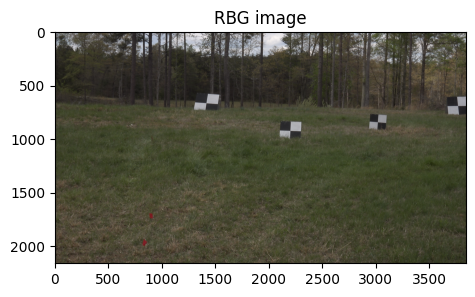

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

try:
  im = axes.imshow(img_bbvisright[:, :, [0,1,2]])
  axes.set_title('RBG image')

  axes.label_outer()
  plt.show()

except Exception as e:
  print(e)

Plotting the LWHSI cube

/tmp/ipykernel_4868/847270647.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


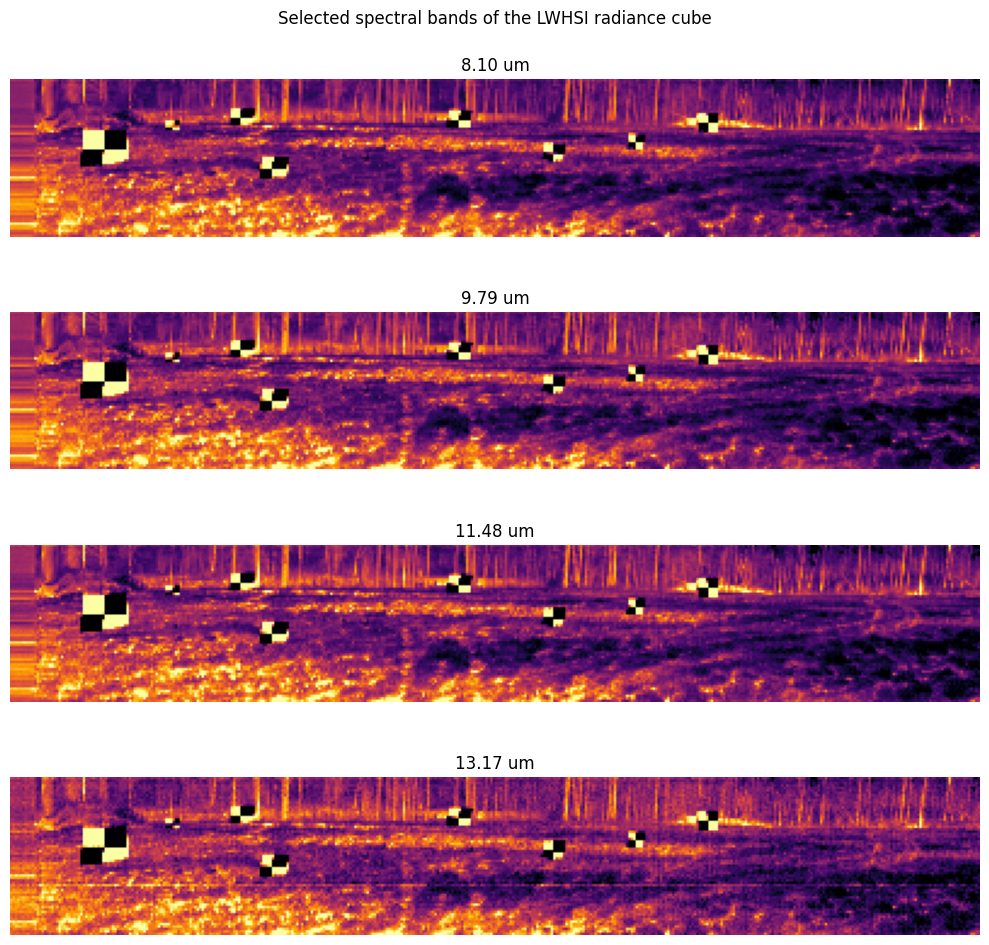

In [11]:
try:
  if hasattr(img, 'bands') and 'wavelength' in img.metadata:
        wavelengths_um = [float(w) for w in img.metadata['wavelength']]
  else:
      num_bandas = radiance_hsi.shape[2]
      wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

  band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
  plot_stride = 4

  fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
  axes = axes.ravel()

  for ax, band_index in zip(axes, band_indices):
      band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
      im = ax.imshow(robust_image(band_image), cmap='inferno')
      ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
      ax.axis('off')

  fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
  plt.tight_layout()
  plt.show()
except Exception as e:
    print(f'Error: {e}')

You can select whatever band you want (the images have a total of 256 bands)

/tmp/ipykernel_4868/847270647.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


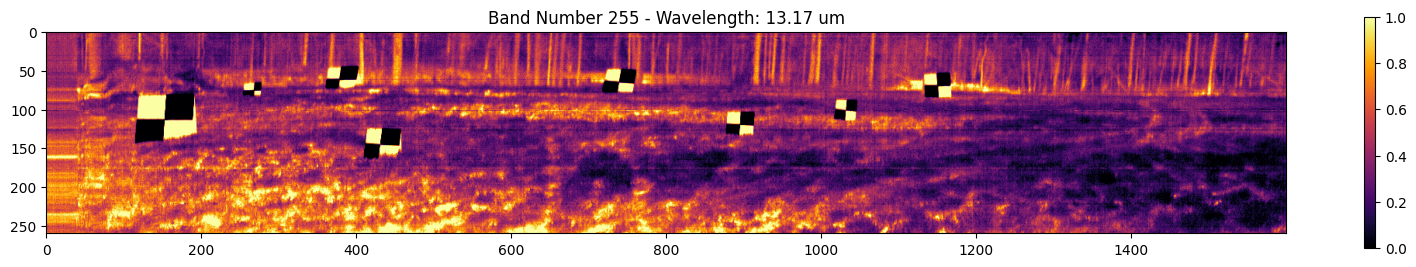

In [12]:
fig, axes = plt.subplots(1, 1, figsize=(20, 3))

# Change the current band with this variable
selected_band = 255

try:

  im = axes.imshow(robust_image(radiance_hsi[:, :, selected_band]), cmap='inferno')
  axes.set_title(f'Band Number {selected_band} - Wavelength: {wavelengths_um[selected_band]:.2f} um')

  axes.label_outer()
  plt.colorbar(im, ax=axes)
  plt.show()

except Exception as e:
  print(e)


Select the pixels you want to plot (image shape is (260,1600,256)) on the image

In [13]:
# Format is (x,y, # pixel, "Pixel #")

selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

Select the temperature in Kelvin

In [14]:
# Modify the temperature value with this variable
temperature_k = 300

/tmp/ipykernel_4868/847270647.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


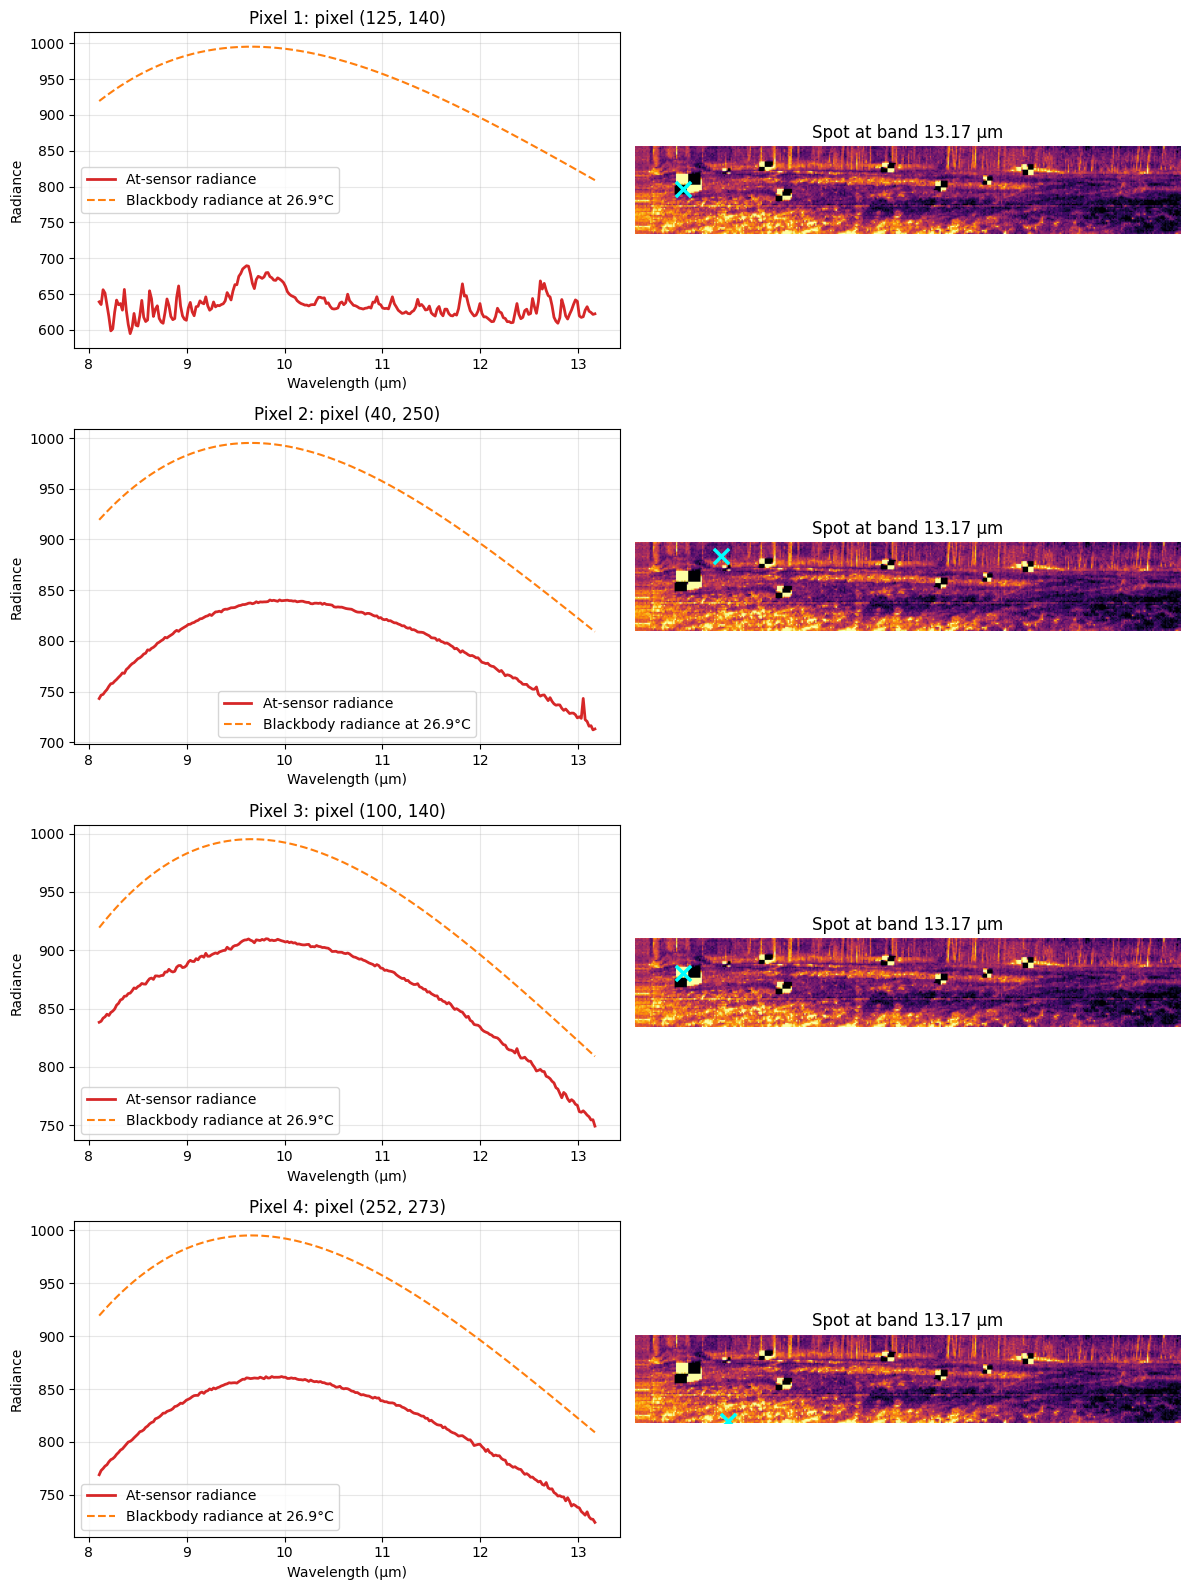

In [42]:
selected_pixels = [
    (125, 140, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (100, 140, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

/tmp/ipykernel_4868/847270647.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


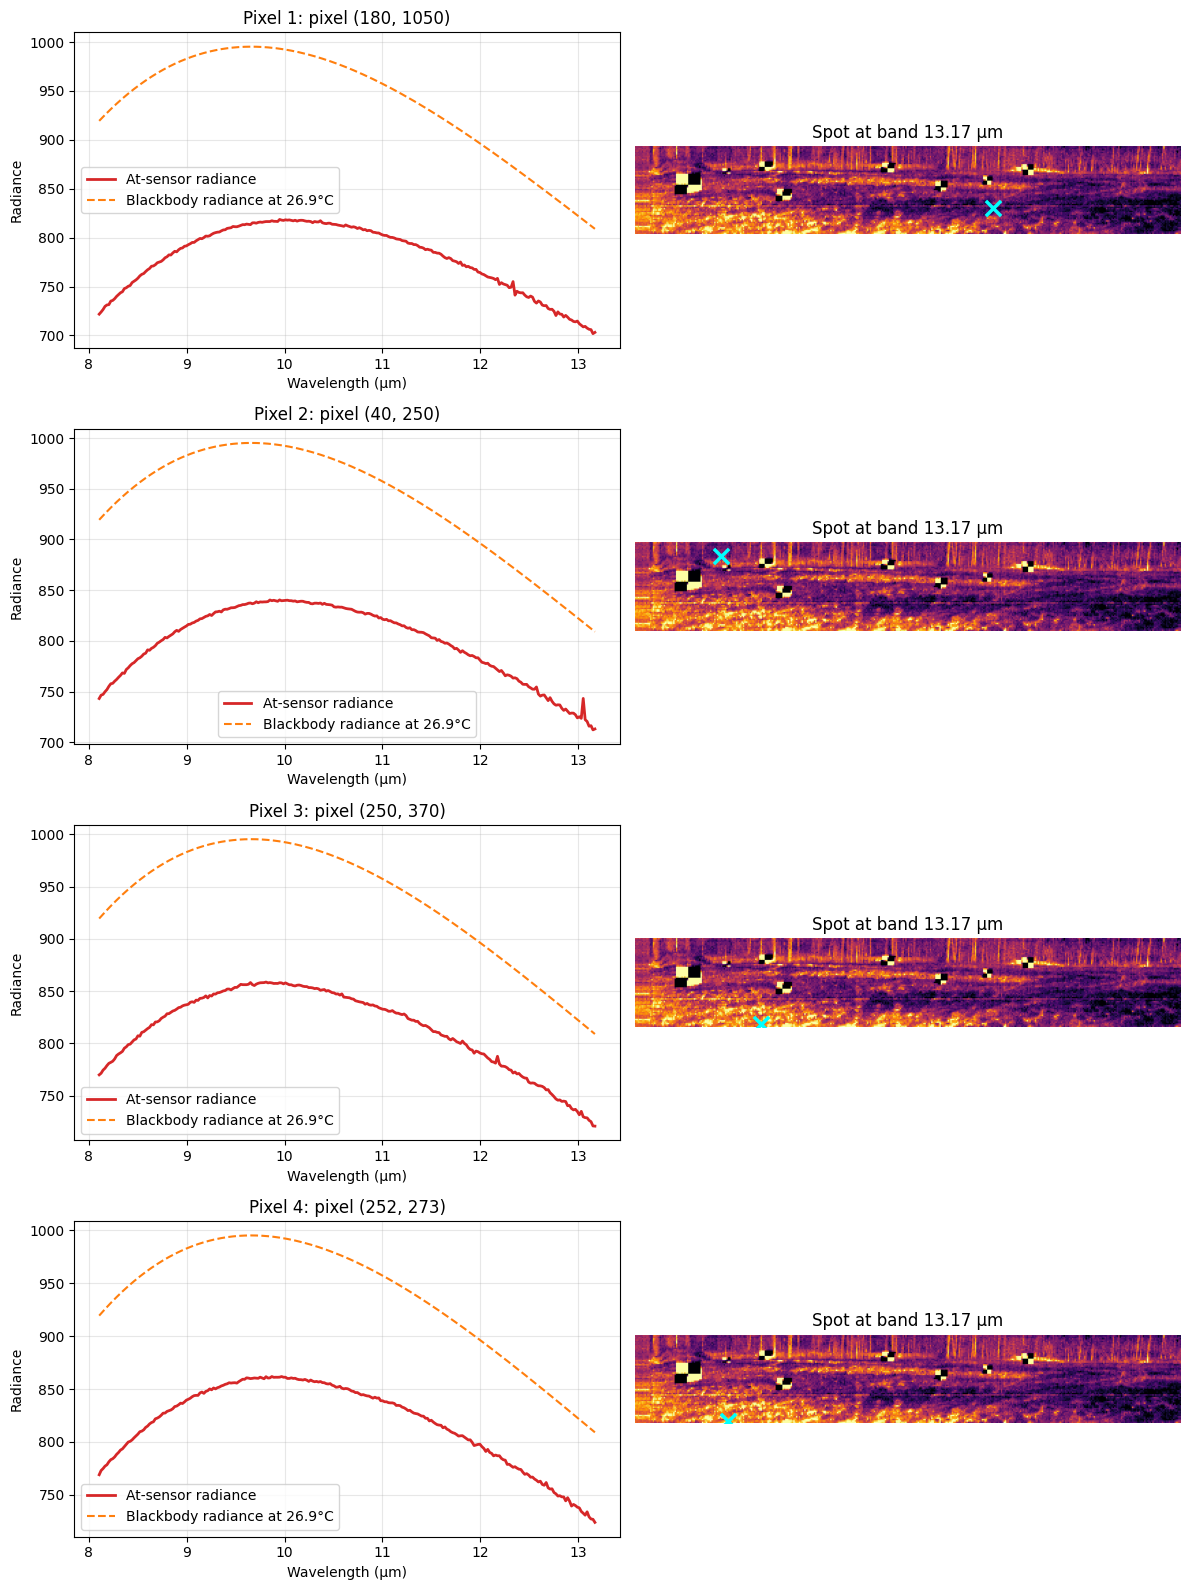

In [15]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

# LIDAR (DEPTH TRUTH)

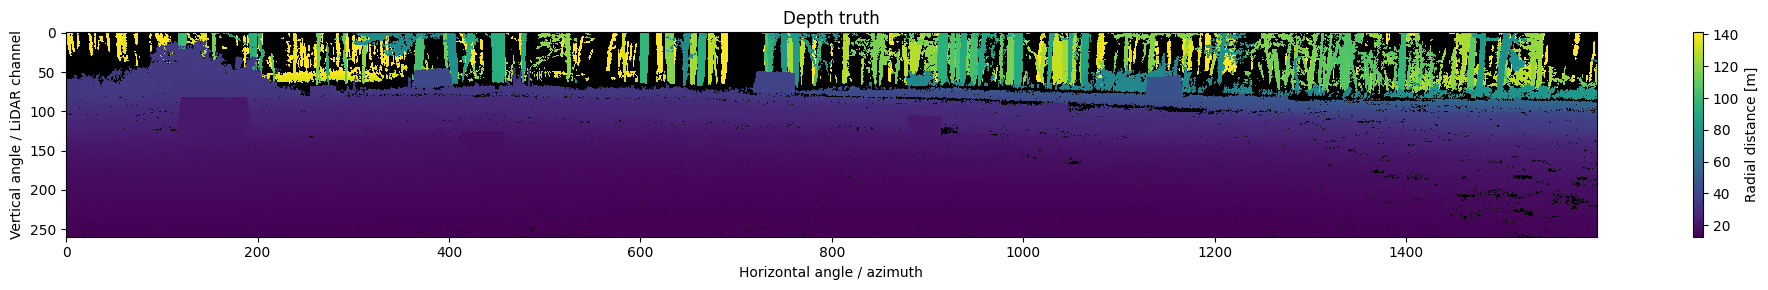

In [16]:
plot_range_image(
      depth_truth,
      title="Depth truth",
      crop=True,
      inverse_depth=False
  )

# EMISSIVITY TRUTH

Loading reflectance obtained in the Ecostress Spectral Library

In [17]:
vegetation = sorted(list(Path("/content/").glob("**/vegetation/*.txt")))
soil = sorted(list(Path("/content/").glob("**/soil/*.txt")))
manmade = sorted(list(Path("/content/").glob("**/manmade/*.txt")))

soil_wavelength, soil_emissivity = emissivity_and_wavelength(soil[47])
grass_wavelength, grass_emissivity = emissivity_and_wavelength(vegetation[8])
tree_wavelength, tree_emissivity = emissivity_and_wavelength(manmade[31])
calibrationpoints_wavelength, calibrationpoints_emissivity = emissivity_and_wavelength(manmade[45])
leaves_wavelength, leaves_emissivity = emissivity_and_wavelength(vegetation[1768])

/content/ecostress_spectral/ecostress/soil/soil.entisol.none.unsorted.tir.fgg003.jpl.nicolet.spectrum.txt
/content/ecostress_spectral/ecostress/vegetation/vegetation.grass.unknown.unknown.all.grass.jhu.becknic.spectrum.txt
/content/ecostress_spectral/ecostress/manmade/manmade.generalconstructionmaterial.wood.solid.all.0404uuuwod.jhu.becknic.spectrum.txt
/content/ecostress_spectral/ecostress/manmade/manmade.reflectancetarget.none.solid.tir.ilf-17464-2-2-tc.jpl.nicolet.spectrum.txt
/content/ecostress_spectral/ecostress/vegetation/vegetation.tree.quercus.lobata.tir.vh282.ucsb.nicolet.spectrum.txt


Using K-Means to segment both the RGB and LWHSI images and get the emissivity truth map

In [18]:
h, w, h2, w2, rgb_centers, labels_rgb, kmeans_lwhsi, labels_lwhsi_2d = segmentation_maps(5, img_bbvisright, radiance_hsi)

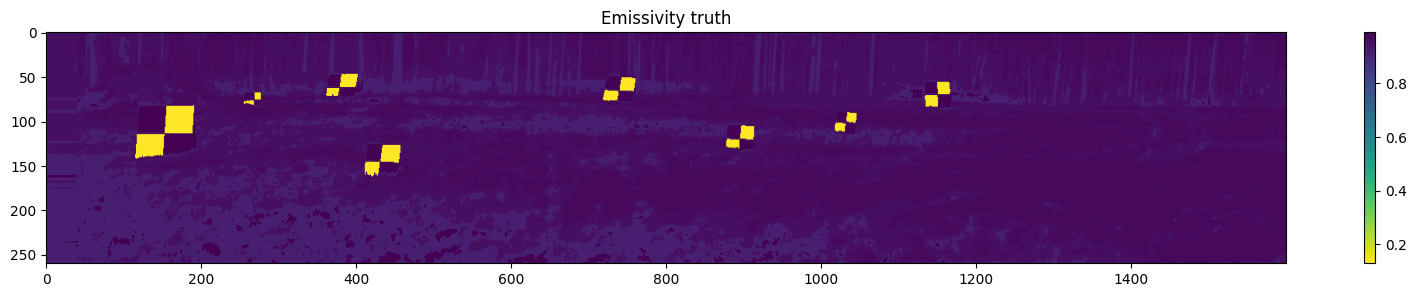

In [19]:
emissivity_map = emissivity_truth_map(h,
                     w,
                     h2,
                     w2,
                     rgb_centers,
                     labels_rgb,
                     kmeans_lwhsi,
                     labels_lwhsi_2d,
                     calibrationpoints_emissivity,
                     soil_emissivity,
                     leaves_emissivity,
                     tree_emissivity,
                     grass_emissivity,
                     wavelengths_um,
                     calibrationpoints_wavelength,
                     soil_wavelength,
                     leaves_wavelength,
                     tree_wavelength,
                     grass_wavelength)

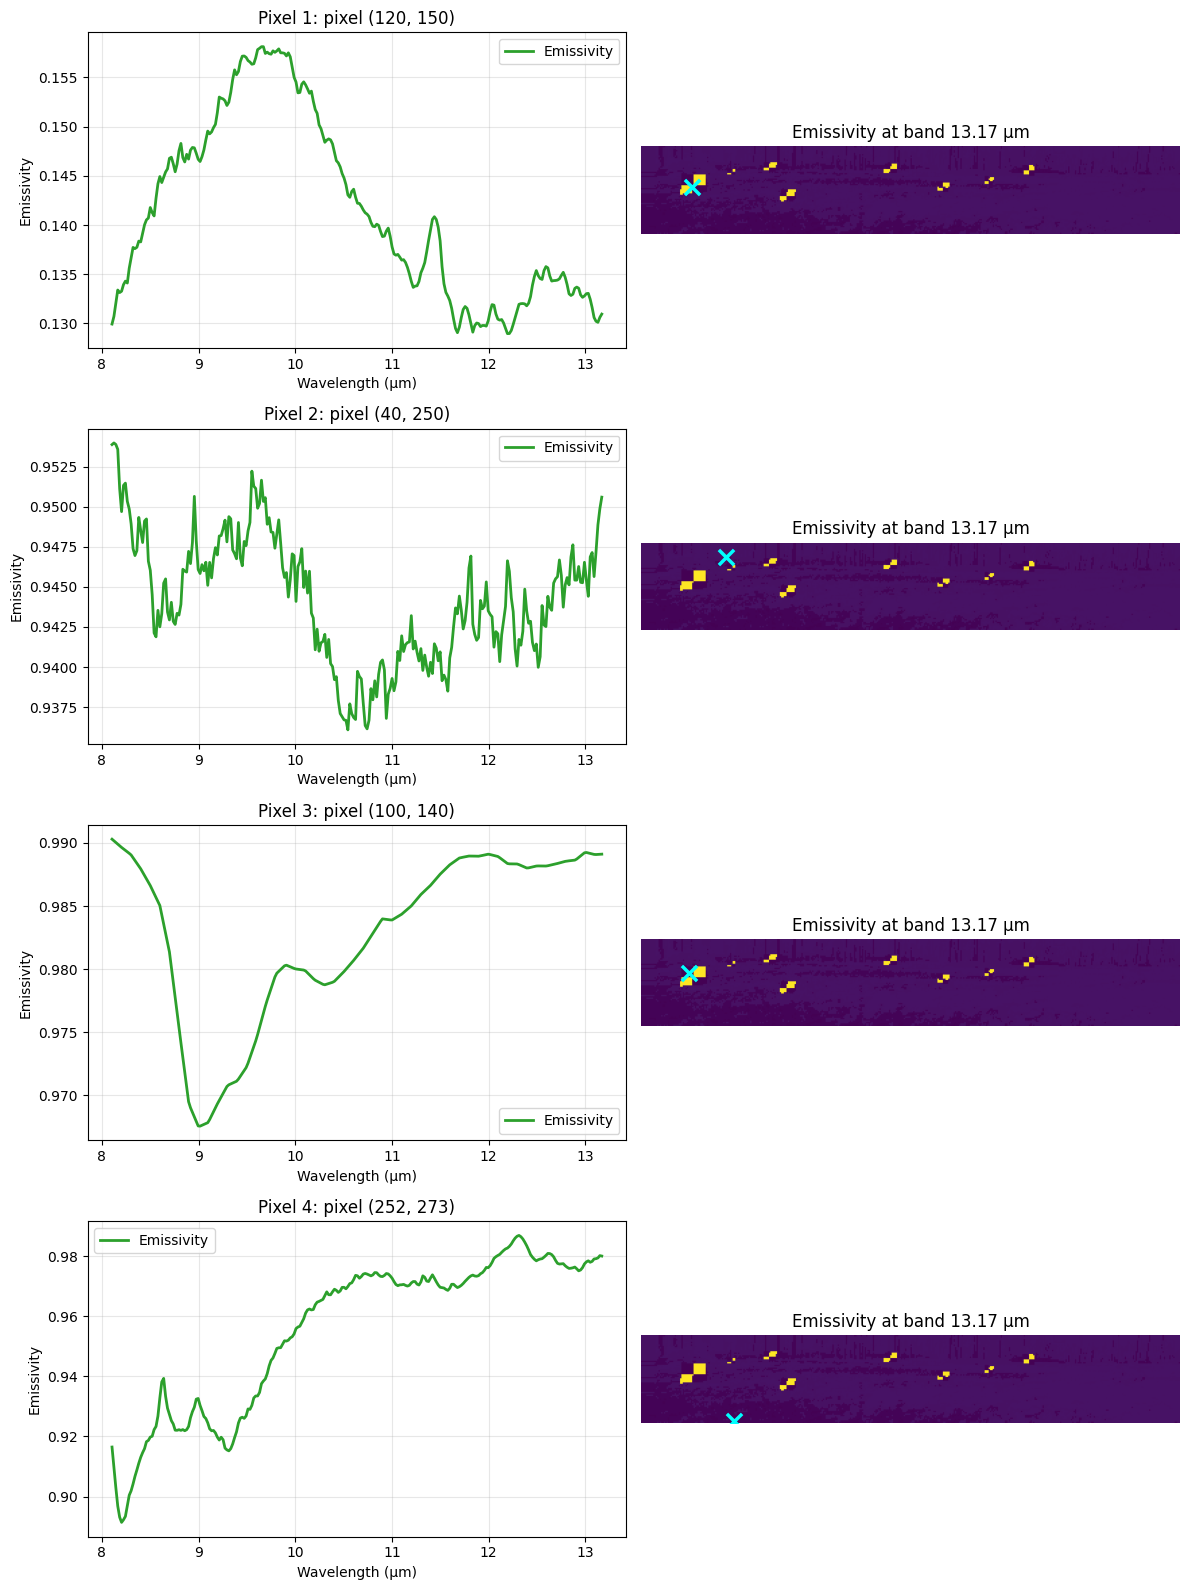

In [37]:
wavelengths_um = np.array(wavelengths_um)
context_image = emissivity_map[::plot_stride, ::plot_stride, selected_band]

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, emissivity_map[row, col, :].flatten(), color='tab:green', linewidth=2, label='Emissivity')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Emissivity')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='viridis_r', aspect='equal')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Emissivity at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()

# TEMPERATURE TRUTH

In [21]:
temperature_map = invert_blackbody_temperature(wavelengths_um, radiance_hsi, emissivity=emissivity_map)

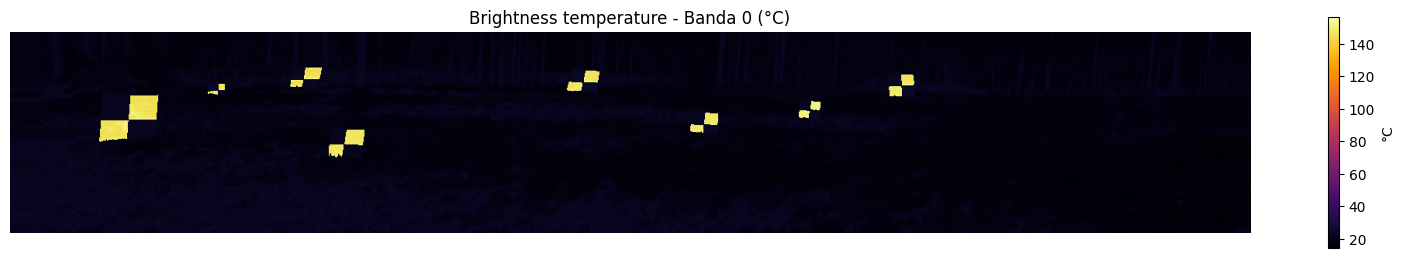

In [30]:
temperature_truth_map(temperature_map, 0, title="Brightness temperature", in_celsius=True)

In [23]:
valid_depths = depth_truth[~np.isnan(depth_truth)]
default_depth = np.median(valid_depths) if valid_depths.size > 0 else 10.0

clean_depth = np.nan_to_num(depth_truth, nan=default_depth)

interpolated_attenuation = np.interp(
    wavelengths_um,
    lambda_atm,
    attenuation_map
).astype(np.float32)

transmittance_cube = np.exp(-clean_depth[..., np.newaxis] * interpolated_attenuation[np.newaxis, np.newaxis, :])

panel_mask = (temperature_map[:, :, selected_band] > 370)
num_pixels = np.sum(panel_mask)
print(f"Píxeles a los que se les aplica la corrección: {num_pixels}")
l_down_vector = np.mean(l_downwelling, axis=1)
air_blackbody_spectrum = l_downwelling[:, -1]

interpolated_l_down = np.interp(
    wavelengths_um,
    lambda_atm,
    l_down_vector
)

interpolated_emissivity = np.interp(
    wavelengths_um,
    calibrationpoints_wavelength,
    calibrationpoints_emissivity
)

fixed_radiance = radiance_hsi.copy()
panel_mask = (temperature_map[:, :, selected_band] > 370.0)

if np.any(panel_mask):
    sensor_panel = radiance_hsi[panel_mask, :]
    tau_panel = transmittance_cube[panel_mask, :]

    air_bb_1d = np.reshape(air_blackbody_spectrum, (1, -1))
    l_down_1d = np.reshape(interpolated_l_down, (1, -1))

    # CORRECCIÓN: Extraer la emisividad espacial real del mapa para cada píxel y banda
    # shape resultante: (4853, num_bands)
    emissivity_panel = emissivity_map[panel_mask, :]

    # Aplicar la RTE usando la emisividad específica de cada píxel
    surface_leaving = (sensor_panel - (1.0 - tau_panel) * air_bb_1d) / tau_panel
    pure_emission = surface_leaving - (1.0 - emissivity_panel) * l_down_1d

    fixed_radiance[panel_mask, :] = np.maximum(pure_emission, 1e-12)


fixed_temperature = invert_blackbody_temperature(wavelengths_um, fixed_radiance, emissivity=emissivity_map)

fixed_temp_celsius = fixed_temperature - 273.15

panel_temps_c = fixed_temp_celsius[panel_mask]
print(f"Mínima corregida: {np.min(panel_temps_c):.2f} °C")
print(f"Máxima corregida: {np.max(panel_temps_c):.2f} °C")
print(f"Promedio corregido: {np.mean(panel_temps_c):.2f} °C")

Píxeles a los que se les aplica la corrección: 4853


/tmp/ipykernel_4868/759497951.py:47: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  surface_leaving = (sensor_panel - (1.0 - tau_panel) * air_bb_1d) / tau_panel


Mínima corregida: -88.72 °C
Máxima corregida: 145.87 °C
Promedio corregido: 86.75 °C


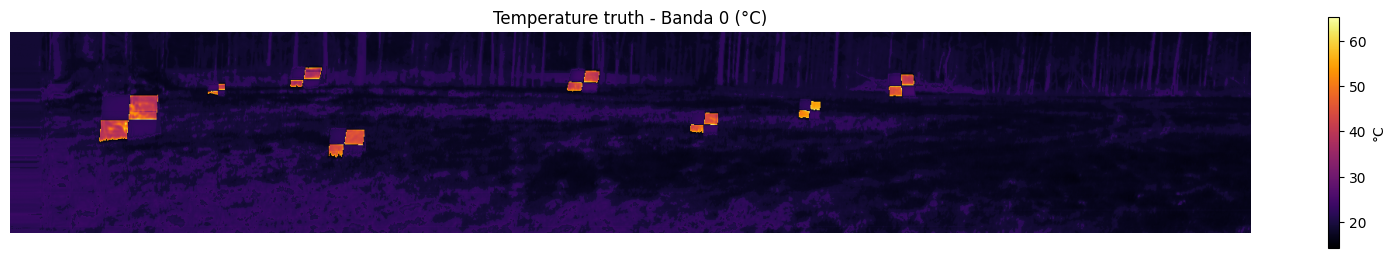

In [ ]:
temperature_truth_map(fixed_temperature, 0, title="Temperature truth", in_celsius=True)

# P1

# Basic Gradiant Descent

In [43]:
# Assuming dimensions based on radiance_hsi.shape (260, 1600, 256)
h, w, bands = radiance_hsi.shape


depth = depth_truth

band_idx = int(np.argmin(np.abs(wavelengths_um - 10.0)))

temperature_c = invert_blackbody_temperature(
    wavelengths_um[band_idx],
    radiance_hsi[:, :, band_idx],
    emissivity=1.0
) - 273.15  # a Celsius

temperature_c = temperature_c[:,:,None]


emissivity = emissivity_map

# Placeholder for air_temperature_c (scalar). Replace with actual data if available.
air_temperature_c = 25.0


#downwelling_radiance = np.full(bands, 100.0, dtype=np.float32) #***
downwelling_radiance = l_downwelling[:, -1]

#attenuation_db_per_m = np.load(os.path.join(data_path, 'attenuation.npy')).astype(np.float32)
#waves = np.load(os.path.join(data_path, 'wavelengths.npy')).astype(np.float32)

#attenuation_db_per_m = np.interp(wavelengths_um, waves, attenuation_db_per_m)

attenuation_db_per_m = attenuation_map

In [44]:
def transmittance(depth_map):
    """Atmospheric transmittance for every wavelength using attenuation in dB/m."""
    optical_loss_db = attenuation_db_per_m[None, None, :] * depth_map[:, :, None]
    return (10 ** (-optical_loss_db / 10.0)).astype(np.float32)


def d_blackbody_radiance_d_temperature(wavelengths_um,temperature_k_map):
    """Derivative of blackbody radiance with respect to temperature in Kelvin."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um[None, None, :] * 1e-6
    temperature_k_map = temperature_k_map[:, :, None]

    x = (h * c) / (wavelength_m * k * temperature_k_map)
    exp_x = np.exp(x)
    scale = (2.0 * h * c**2) / wavelength_m**5 * 1e-6 * MICROFLICK_PER_W_M2
    derivative = scale * exp_x * x / (temperature_k_map * (exp_x - 1.0) ** 2)
    return derivative.astype(np.float32)


def plot_truth_prediction_error(truth, prediction, title, unit, cmap='viridis'):
    error = np.abs(prediction - truth)
    vmin = min(float(np.min(truth)), float(np.min(prediction)))
    vmax = max(float(np.max(truth)), float(np.max(prediction)))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    im0 = axes[0].imshow(truth, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'{title} truth')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label=unit)

    im1 = axes[1].imshow(prediction, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'{title} prediction')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label=unit)

    im2 = axes[2].imshow(error, cmap='magma')
    axes[2].set_title(f'{title} absolute error')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label=unit)

    plt.tight_layout()
    plt.show()


def plot_temperature_image(temperature_img, title="Brightness temperature", in_celsius=True):
    img = temperature_img - 273.15 if in_celsius else temperature_img
    unit = "°C" if in_celsius else "K"

    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(img, cmap='inferno')
    ax.set_title(f"{title} ({unit})")
    ax.axis('off')
    plt.colorbar(im, ax=ax, label=unit)
    plt.show()

## Manual Basic Gradient Descent

In [50]:
def manual_gradient_descent(
    observed_radiance,
    air_temperature_c,
    downwelling_radiance,
    iterations=800,
    record_every=50,
    initial_emissivity=0.9,
    initial_depth=20.0,
    initial_temperature_c=20.0,
    learning_rate_emissivity=1e-2,
    learning_rate_depth=1e2,
    learning_rate_temperature=20.0,
    depth_truth=None,
    temperature_truth_c=None,
    emissivity_truth=None,
):
    """Estimate emissivity, depth, and object temperature.

    T_air and the incident downwelling radiance are fixed inputs.
    They are used by the RTE but are not estimated here.
    """
    observed_radiance = np.asarray(
        observed_radiance,
        dtype=np.float32,
    )
    n_bands = observed_radiance.shape[2]
    radiance_scale = np.maximum(
        np.mean(
            observed_radiance,
            axis=2,
            keepdims=True,
        ),
        1.0,
    )

    #Initial Values
    predicted_emissivity = np.full_like(
        observed_radiance,
        initial_emissivity,
        dtype=np.float32,
    )
    predicted_depth = np.full(
        observed_radiance.shape[:2],
        initial_depth,
        dtype=np.float32,
    )
    predicted_temperature_k = np.full(
        observed_radiance.shape[:2],
        initial_temperature_c + 273.15,
        dtype=np.float32,
    )

    # Constant Values
    air_temperature_k = np.array(
        [[air_temperature_c + 273.15]],
        dtype=np.float32,
    )
    air_blackbody = blackbody_radiance(
        wavelengths_um, air_temperature_k
    )

    fixed_downwelling = np.asarray(
        downwelling_radiance,
        dtype=np.float32,
    )
    if fixed_downwelling.ndim == 1:
        fixed_downwelling = (
            fixed_downwelling[None, None, :]
        )
    if fixed_downwelling.shape[-1] != n_bands:
        raise ValueError(
            'downwelling_radiance must have one value per band.'
        )
    try:
        fixed_downwelling = np.broadcast_to(
            fixed_downwelling,
            observed_radiance.shape,
        )
    except ValueError as exc:
        raise ValueError(
            'downwelling_radiance must broadcast to '
            'observed_radiance.'
        ) from exc

    attenuation_factor = (
        -(np.log(10.0) / 10.0)
        * attenuation_db_per_m[None, None, :]
    )
    history = []

    for iteration in range(iterations + 1):
        blackbody = blackbody_radiance(
            wavelengths_um, predicted_temperature_k
        )
        transmittance_term = transmittance(
            predicted_depth
        )

        # Forward
        surface_leaving = (
            predicted_emissivity * blackbody
            + (1.0 - predicted_emissivity)
            * fixed_downwelling
        )
        prediction = (
            transmittance_term * surface_leaving
            + (1.0 - transmittance_term)
            * air_blackbody
        )


        normalized_error = (
            prediction - observed_radiance
        ) / radiance_scale
        loss = np.mean(normalized_error**2)

        if (
            iteration % record_every == 0
            or iteration == iterations
        ):
            row = {
                'iteration': iteration,
                'normalized_radiance_rmse': float(
                    np.sqrt(loss)
                ),
            }
            if depth_truth is not None:
                row['depth_rmse'] = float(
                    np.sqrt(
                        np.nanmean(
                            (
                                predicted_depth
                                - depth_truth
                            ) ** 2
                        )
                    )
                )
            if temperature_truth_c is not None:
                predicted_temperature_c = (
                    predicted_temperature_k - 273.15
                )
                row['temperature_rmse'] = float(
                    np.sqrt(
                        np.nanmean(
                            (
                                predicted_temperature_c
                                - temperature_truth_c
                            ) ** 2
                        )
                    )
                )
            if emissivity_truth is not None:
                row['emissivity_rmse'] = float(
                    np.sqrt(
                        np.mean(
                            (
                                predicted_emissivity
                                - emissivity_truth
                            ) ** 2
                        )
                    )
                )
            history.append(row)

        if iteration == iterations:
            break

        residual_factor = (
            (2.0 / n_bands)
            * (prediction - observed_radiance)
            / (radiance_scale**2)
        )

        # Gradients
        grad_emissivity = (
            residual_factor
            * transmittance_term
            * (blackbody - fixed_downwelling)
        )

        grad_depth = np.sum(
            residual_factor
            * (surface_leaving - air_blackbody)
            * attenuation_factor
            * transmittance_term,
            axis=2,
        )

        grad_temperature = np.sum(
            residual_factor
            * predicted_emissivity
            * transmittance_term
            * d_blackbody_radiance_d_temperature(
                wavelengths_um, predicted_temperature_k
            ),
            axis=2,
        )

        # New Values
        predicted_emissivity = np.clip(
            predicted_emissivity
            - learning_rate_emissivity
            * grad_emissivity,
            0.6,
            1.0,
        )
        predicted_depth = np.clip(
            predicted_depth
            - learning_rate_depth * grad_depth,
            0.0,
            120.0,
        )
        predicted_temperature_k = np.clip(
            predicted_temperature_k
            - learning_rate_temperature
            * grad_temperature,
            273.15,
            313.15,
        )

    return {
        'emissivity': predicted_emissivity,
        'depth': predicted_depth,
        'temperature_c': (
            predicted_temperature_k - 273.15
        ),
        'history': history,
    }


## Basic Visualization

In [51]:
def blackbody_radiance(wavelengths_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelengths_um = np.asarray(wavelengths_um, dtype=np.float32)
    temperature_k = np.asarray(temperature_k, dtype=np.float32)

    # Reshape wavelengths_um for broadcasting with temperature_k
    wavelength_m = wavelengths_um.reshape((1,) * temperature_k.ndim + wavelengths_um.shape) * 1e-6
    temperature_k_b = temperature_k[..., None]

    # Use temperature_k_b for correct broadcasting
    x = (h * c) / (wavelength_m * k * temperature_k_b)
    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

In [52]:
backward_stride = 16

observed_small = radiance_hsi[::backward_stride, ::backward_stride, :]
depth_truth_small = depth[::backward_stride, ::backward_stride]
temperature_truth_small = temperature_c[::backward_stride, ::backward_stride]
emissivity_truth_small = emissivity[::backward_stride, ::backward_stride, :]

inverse_result = manual_gradient_descent(
    observed_small,
    air_temperature_c=air_temperature_c,
    downwelling_radiance=downwelling_radiance,
    iterations=300,
    record_every=50,
    depth_truth=depth_truth_small,
    temperature_truth_c=temperature_truth_small,
    emissivity_truth=emissivity_truth_small,
)

print('Estimated emissivity:', inverse_result['emissivity'].shape)
print('Estimated depth:', inverse_result['depth'].shape)
print('Estimated temperature:', inverse_result['temperature_c'].shape)
print('Final metrics:', inverse_result['history'][-1])


Estimated emissivity: (17, 100, 256)
Estimated depth: (17, 100)
Estimated temperature: (17, 100)
Final metrics: {'iteration': 300, 'normalized_radiance_rmse': 0.005917278118431568, 'depth_rmse': 38.53381735286466, 'temperature_rmse': 2.348219156265259, 'emissivity_rmse': 0.09815454483032227}


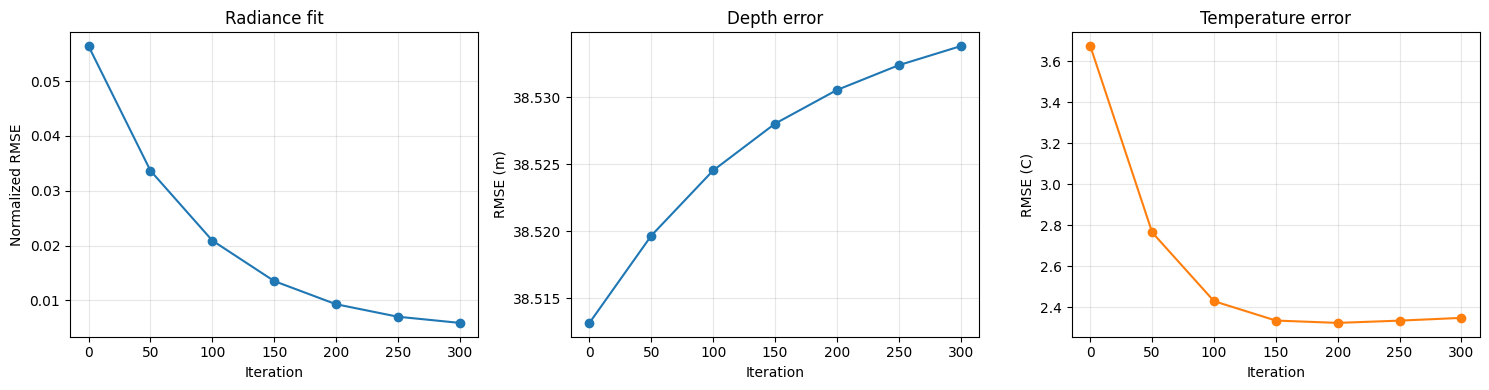

In [53]:
history = inverse_result['history']
iterations = [row['iteration'] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(iterations, [row['normalized_radiance_rmse'] for row in history], marker='o')
axes[0].set_title('Radiance fit')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalized RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [row['depth_rmse'] for row in history], marker='o', color='tab:blue')
axes[1].set_title('Depth error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (m)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, [row['temperature_rmse'] for row in history], marker='o', color='tab:orange')
axes[2].set_title('Temperature error')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE (C)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


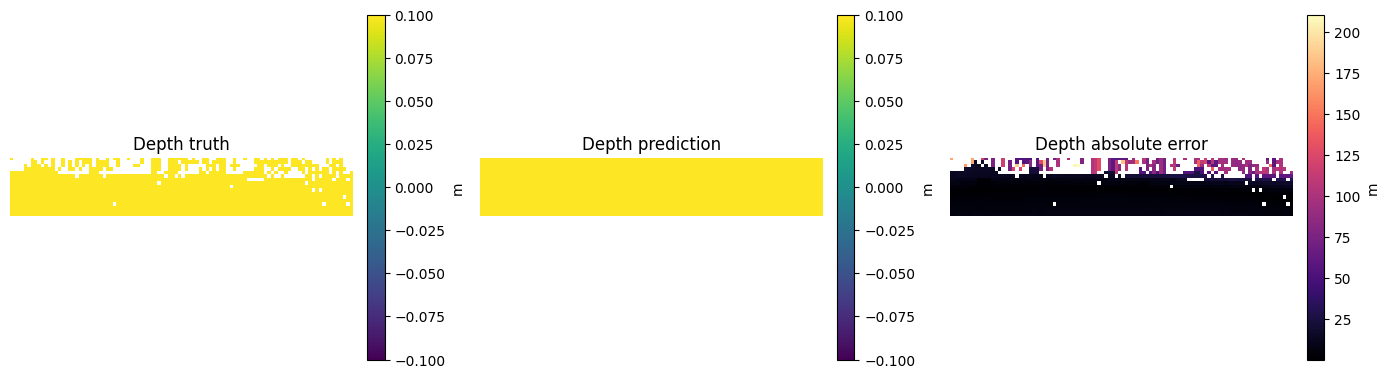

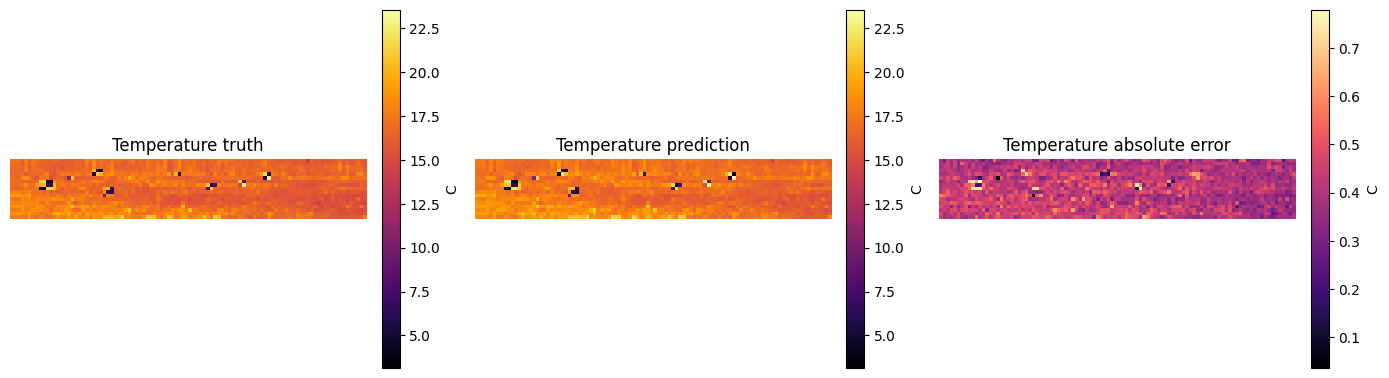

In [54]:
plot_truth_prediction_error(depth_truth_small, inverse_result['depth'], 'Depth', 'm')
plot_truth_prediction_error(
    np.squeeze(temperature_truth_small), inverse_result['temperature_c'], 'Temperature', 'C', cmap='inferno'
)


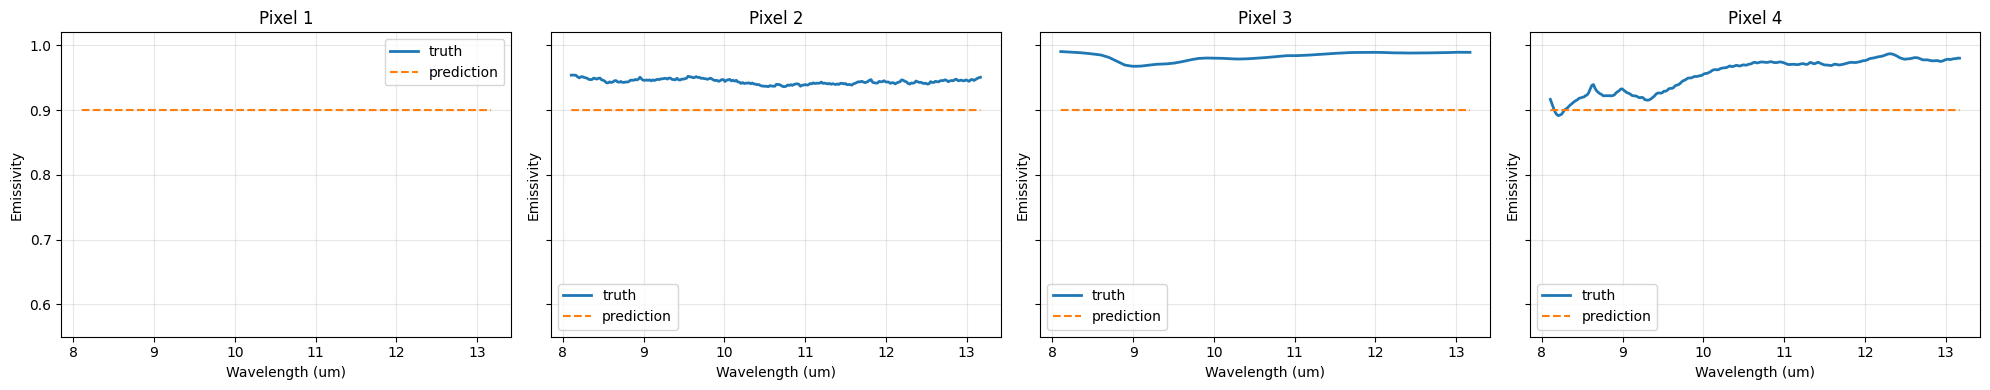

Selected-pixel emissivity RMSE: 0.38347741961479187


In [55]:
selected_rows = np.array([pixel[0] for pixel in selected_pixels])
selected_cols = np.array([pixel[1] for pixel in selected_pixels])
selected_names = [pixel[3] for pixel in selected_pixels]

selected_small_rows = selected_rows // backward_stride
selected_small_cols = selected_cols // backward_stride
emissivity_truth_pixels = emissivity[selected_rows, selected_cols, :]
emissivity_prediction_pixels = inverse_result['emissivity'][selected_small_rows, selected_small_cols, :]

fig, axes = plt.subplots(1, len(selected_names), figsize=(5 * len(selected_names), 4), sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for i, (ax, material_name) in enumerate(zip(axes, selected_names)):
    ax.plot(wavelengths_um, emissivity_truth_pixels[i, :], label='truth', linewidth=2)
    ax.plot(wavelengths_um, emissivity_prediction_pixels[i, :], label='prediction', linestyle='--')
    ax.set_title(material_name)
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Emissivity')
    ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Selected-pixel emissivity RMSE:', float(np.sqrt(np.mean((emissivity_prediction_pixels - emissivity_truth_pixels) ** 2))))


In [56]:
# Uso, calcado del patrón que usó tu compañero para LiDAR:
temperature_img, used_wavelength = compute_temperature_image(
    radiance_hsi, wavelengths_um, band_wavelength=10.0, emissivity=1.0
)
print(f"Usando banda a {used_wavelength:.2f} um")
plot_temperature_image(temperature_img, title="Brightness temperature (emissivity=1)")

# opcional: con una emisividad típica de terreno natural en vez de 1.0
temperature_img_e95, _ = compute_temperature_image(
    radiance_hsi, wavelengths_um, band_wavelength=10.0, emissivity=0.95
)
plot_temperature_image(temperature_img_e95, title="Brightness temperature (emissivity=0.95)")

NameError: name 'compute_temperature_image' is not defined

In [ ]:
# ---- 1. wavelengths ya los tienes de la carga ENVI ----
wavelengths_um = np.array(wavelengths_um, dtype=np.float32)
n_bands = radiance_hsi.shape[2]

# ---- 2. parámetros físicos fijos (mientras no tengas calibración real) ----
air_temperature_c = 20.0                                         #
downwelling_radiance = blackbody_radiance(
    wavelengths_um, np.float32(air_temperature_c + 273.15 - 5)   # aprox: cielo unos grados más frío que el aire
)

# ---- 3. downsample, igual que hizo tu compañero con max_points ----
stride = 8
observed_small = radiance_hsi[::stride, ::stride, :]

# Prepare truth values for the current stride
depth_truth_small = depth[::stride, ::stride]
temperature_truth_small = temperature_c[::stride, ::stride]
emissivity_truth_small = emissivity[::stride, ::stride, :]

# ---- 4. warm start: arranca la temperatura desde la brillo-temperatura,
#         en vez de un valor plano — converge más rápido y más estable ----
band_idx = int(np.argmin(np.abs(wavelengths_um - 10.0)))
warm_start_temp_c = np.squeeze(invert_blackbody_temperature(
    wavelengths_um[band_idx], observed_small[:, :, band_idx], emissivity=0.95
)) - 273.15

# ---- 5. correr la inversión (SIN los learning rates originales de 1e6!) ----
result = manual_gradient_descent(
    observed_small,
    air_temperature_c=air_temperature_c,
    downwelling_radiance=downwelling_radiance,
    iterations=1500,
    record_every=100,
    initial_temperature_c=warm_start_temp_c,   # mapa, no escalar
    initial_depth=20.0,
    initial_emissivity=0.9,
    learning_rate_emissivity=5e-3,
    learning_rate_depth=2e2,
    learning_rate_temperature=5.0,
    depth_truth=depth_truth_small, # Pass depth truth
    temperature_truth_c=temperature_truth_small, # Pass temperature truth
    emissivity_truth=emissivity_truth_small, # Pass emissivity truth
)


plot_temperature_image(result['temperature_c'])

for row in result['history']:
    print(row)

In [ ]:
history = result['history']
iterations = [row['iteration'] for row in history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(iterations, [row['normalized_radiance_rmse'] for row in history], marker='o')
axes[0].set_title('Radiance fit')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Normalized RMSE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iterations, [row['depth_rmse'] for row in history], marker='o', color='tab:blue')
axes[1].set_title('Depth error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (m)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(iterations, [row['temperature_rmse'] for row in history], marker='o', color='tab:orange')
axes[2].set_title('Temperature error')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('RMSE (C)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:

plot_truth_prediction_error(depth_truth_small, result['depth'], 'Depth', 'm')
plot_truth_prediction_error(
    np.squeeze(temperature_truth_small), result['temperature_c'], 'Temperature', 'C', cmap='inferno'
)


In [ ]:
selected_rows = np.array([pixel[0] for pixel in selected_pixels])
selected_cols = np.array([pixel[1] for pixel in selected_pixels])
selected_names = [pixel[3] for pixel in selected_pixels]

selected_small_rows = selected_rows // backward_stride
selected_small_cols = selected_cols // backward_stride
emissivity_truth_pixels = emissivity[selected_rows, selected_cols, :]
emissivity_prediction_pixels = result['emissivity'][selected_small_rows, selected_small_cols, :]

fig, axes = plt.subplots(1, len(selected_names), figsize=(5 * len(selected_names), 4), sharey=True)
if len(selected_names) == 1:
    axes = [axes]

for i, (ax, material_name) in enumerate(zip(axes, selected_names)):
    ax.plot(wavelengths_um, emissivity_truth_pixels[i, :], label='truth', linewidth=2)
    ax.plot(wavelengths_um, emissivity_prediction_pixels[i, :], label='prediction', linestyle='--')
    ax.set_title(material_name)
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Emissivity')
    ax.set_ylim(0.55, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print('Selected-pixel emissivity RMSE:', float(np.sqrt(np.mean((emissivity_prediction_pixels - emissivity_truth_pixels) ** 2))))
